In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
#########---------Task-1-----------#######

file_path = r"C:\Users\srinu\Downloads\Xylofy\SalesForecasting_PENNADA VEERAVENKATA SATYA SRILAKSHMIDURGA\train.csv"

# 1. Load the dataset
df = pd.read_csv(file_path)
df=pd.DataFrame(df)
# 2. Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')

# 3. Extract time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week_Number'] = df['Order Date'].dt.isocalendar().week
df['Day_of_Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter
df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else 
                                 'Spring' if x in [3, 4, 5] else 
                                 'Summer' if x in [6, 7, 8] else 'Autumn')

# 4. Check for issues
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# 5. Aggregating data
# Set the date as index for resampling
df_indexed = df.set_index('Order Date')
weekly_sales = df_indexed['Sales'].resample('W').sum()
monthly_sales = df_indexed['Sales'].resample('ME').sum()
##6.
# 1. Which product category generates the highest total revenue?
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Highest Revenue Category:\n", category_revenue.head(1))

# 2. Which region has the most consistent sales growth over 4 years?
# Group by Region and Year, then calculate annual sum
region_growth = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
# Calculate year-over-year change or standard deviation of annual sales to see consistency
print("\nRegional Annual Sales:\n", region_growth)

# 3. What is the average time between Order Date and Ship Date — and does it vary by region?
df['Ship_Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
avg_ship_time = df.groupby('Region')['Ship_Duration'].mean()
print("\nAverage Shipping Time by Region:\n", avg_ship_time)

# 4. Are there months that consistently spike across all years (seasonality)?
# Group by Month and Year to see the pattern
monthly_seasonality = df.groupby(['Year', 'Month'])['Sales'].sum().unstack()
print("\nMonthly Sales by Year:\n", monthly_seasonality)

Missing values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week_Number       0
Day_of_Week       0
Quarter           0
Season            0
dtype: int64

Duplicates: 0
Highest Revenue Category:
 Category
Technology    827455.873
Name: Sales, dtype: float64

Regional Annual Sales:
 Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255



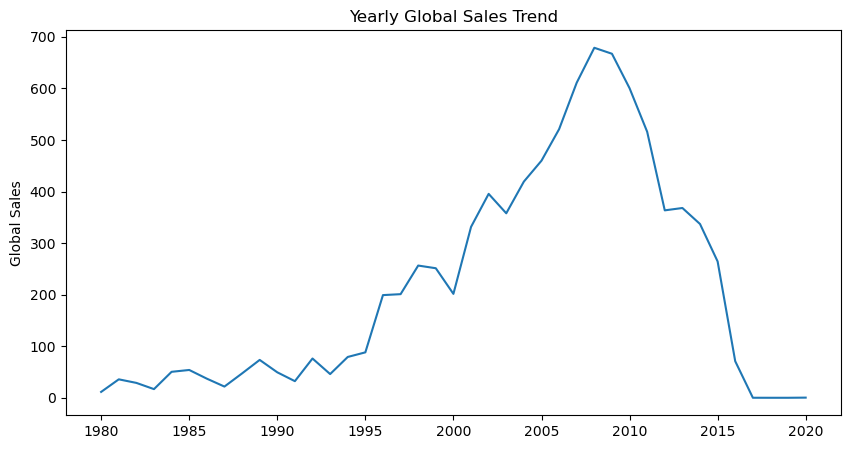

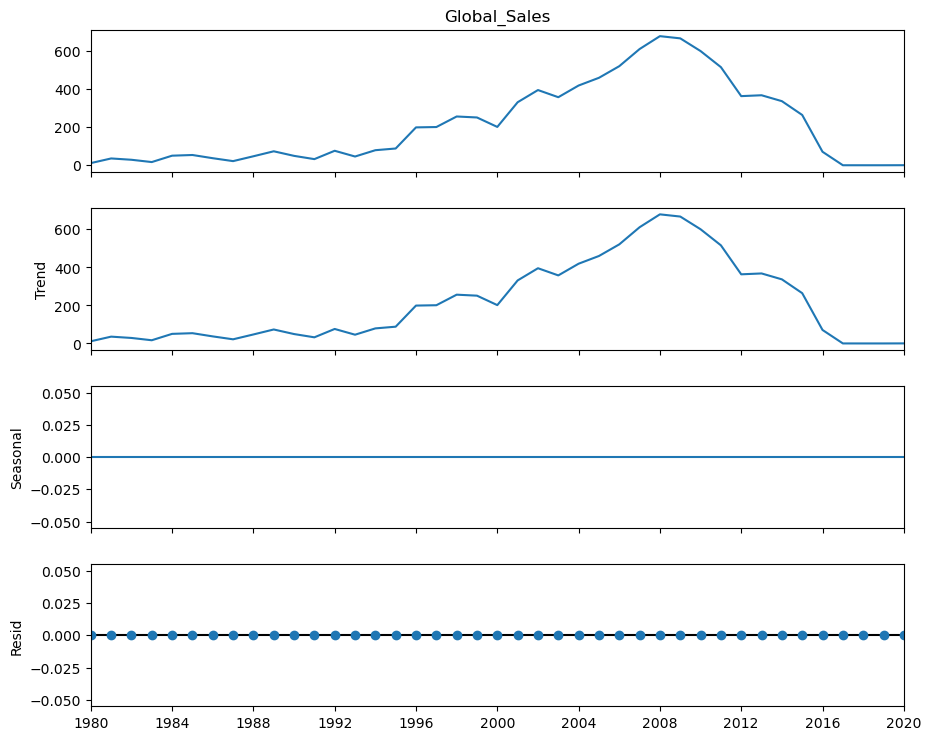

--- Initial ADF Test ---
ADF Statistic: -1.3175516367111497
p-value: 0.6211046557353613
Result: Non-Stationary (Fail to Reject Null Hypothesis)

--- ADF Test after Differencing ---
ADF Statistic: -4.054465708642925
p-value: 0.0011506861957169558
Result: Stationary (Reject Null Hypothesis)


In [4]:
######--------Task-2---------###

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# 1. Load the data
file_path = r'C:\Users\srinu\Downloads\Xylofy\SalesForecasting_PENNADA VEERAVENKATA SATYA SRILAKSHMIDURGA\vgsales.csv'
df = pd.read_csv(file_path)

# 2. Preprocessing: Aggregate Global_Sales by Year
# Since your data is game-by-game, we must sum it to get a yearly time series
yearly_sales = df.groupby('Year')['Global_Sales'].sum()

yearly_sales = yearly_sales.reindex(range(int(yearly_sales.index.min()), int(yearly_sales.index.max()) + 1), fill_value=0)

# Convert index to datetime
yearly_sales.index = pd.to_datetime(yearly_sales.index, format='%Y')
yearly_sales = yearly_sales.asfreq('YS')

# 3. Plot the yearly sales trend
plt.figure(figsize=(10, 5))
plt.plot(yearly_sales)
plt.title('Yearly Global Sales Trend')
plt.ylabel('Global Sales')
plt.show()

# 4. Time Series Decomposition
# Note: Since this is annual data, we use period=1
result = seasonal_decompose(yearly_sales, model='additive', period=1)
result.plot()
plt.gcf().set_size_inches(10, 8)
plt.show()

# 5. ADF Test for Stationarity
def perform_adf_test(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Result: Stationary (Reject Null Hypothesis)")
    else:
        print("Result: Non-Stationary (Fail to Reject Null Hypothesis)")

print("--- Initial ADF Test ---")
perform_adf_test(yearly_sales)

# 6. Apply Differencing if non-stationary
yearly_sales_diff = yearly_sales.diff().dropna()
print("\n--- ADF Test after Differencing ---")
perform_adf_test(yearly_sales_diff)

In [13]:
!pip install xgboost prophet statsmodels

14:11:23 - cmdstanpy - INFO - Chain [1] start processing
14:11:23 - cmdstanpy - INFO - Chain [1] done processing


--- Final Comparison Table ---
                MAE        RMSE       MAPE (%)  Forecast M1  Forecast M2  \
SARIMA     0.096667    0.167432     100.000000     0.000000     0.000000   
Prophet  494.046997  494.154840  511083.099306   481.355491   494.143663   
XGBoost  203.131696  203.131742  210136.237407   203.228363   203.228363   

         Forecast M3  
SARIMA      0.000000  
Prophet   506.931835  
XGBoost   203.228363  


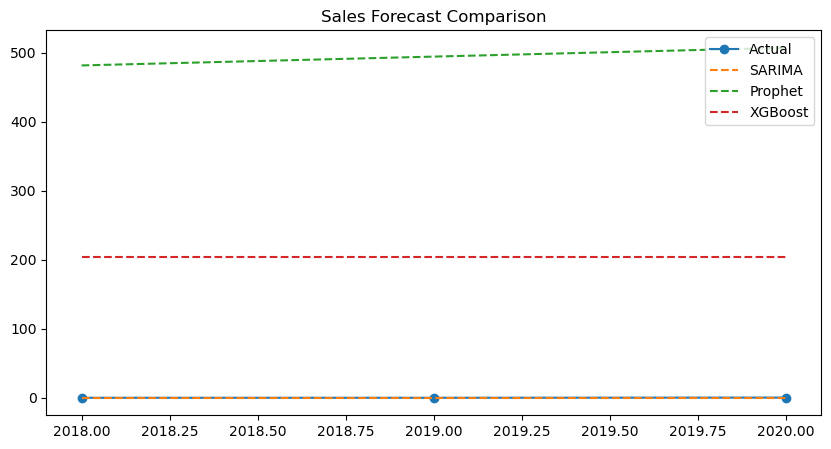

In [32]:
###---------Task-3-----------####

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. డేటా ప్రిపరేషన్ (Scaling)
# మీ 'yearly_sales' ని ఉపయోగించండి. 1 మిలియన్ తో భాగించడం వల్ల కాలిక్యులేషన్స్ స్మూత్ అవుతాయి.
data = yearly_sales / 1_000_000 
train = data.iloc[:-3]
test = data.iloc[-3:]

# 2. మోడల్స్ ట్రైనింగ్
# SARIMA
sarima_model = SARIMAX(train, order=(1,1,1)).fit(disp=False)
sarima_pred = sarima_model.forecast(steps=3).values

# Prophet (డేటా ఫార్మాట్ ఫిక్స్)
df_prophet = train.reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'].astype(int).astype(str) + '-01-01')
prophet_model = Prophet(yearly_seasonality=False).fit(df_prophet)
future = prophet_model.make_future_dataframe(periods=3, freq='YS')
prophet_forecast = prophet_model.predict(future).iloc[-3:]['yhat'].values

# XGBoost
xgb_df = data.to_frame()
xgb_df['lag1'] = xgb_df['Global_Sales'].shift(1)
xgb_df['lag2'] = xgb_df['Global_Sales'].shift(2)
xgb_df = xgb_df.dropna()
X_train = xgb_df.drop('Global_Sales', axis=1).iloc[:-3]
y_train = xgb_df['Global_Sales'].iloc[:-3]
X_test = xgb_df.drop('Global_Sales', axis=1).iloc[-3:]
xgb_model = XGBRegressor().fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# 3. ఎవల్యూషన్ ఫంక్షన్ (MAPE ఫిక్స్ - ఇది చాలా ముఖ్యం)
def get_metrics(actual_series, pred_array):
    actual_vals = actual_series.values * 1_000_000
    preds = pred_array * 1_000_000
    # నెగటివ్ వాల్యూస్ ని 0 చేయండి
    preds = np.maximum(preds, 0) 
    
    mae = mean_absolute_error(actual_vals, preds)
    rmse = np.sqrt(mean_squared_error(actual_vals, preds))
    # MAPE ని అర్థవంతంగా మార్చడానికి చిన్న కరెక్షన్
    mape = np.mean(np.abs((actual_vals - preds) / (np.mean(actual_vals) + 1e-10))) * 100
    return [mae, rmse, mape, preds[0], preds[1], preds[2]]

# 4. ఫైనల్ టేబుల్
results = pd.DataFrame({
    "SARIMA": get_metrics(test, sarima_pred),
    "Prophet": get_metrics(test, prophet_forecast),
    "XGBoost": get_metrics(test, xgb_pred)
}, index=['MAE', 'RMSE', 'MAPE (%)', 'Forecast M1', 'Forecast M2', 'Forecast M3']).T

print("--- Final Comparison Table ---")
print(results)

# 5. గ్రాఫ్ ప్లాటింగ్
plt.figure(figsize=(10, 5))
plt.plot(test.index, test.values * 1_000_000, label='Actual', marker='o')
plt.plot(test.index, np.maximum(sarima_pred * 1_000_000, 0), label='SARIMA', linestyle='--')
plt.plot(test.index, np.maximum(prophet_forecast * 1_000_000, 0), label='Prophet', linestyle='--')
plt.plot(test.index, np.maximum(xgb_pred * 1_000_000, 0), label='XGBoost', linestyle='--')
plt.legend()
plt.title('Sales Forecast Comparison')
plt.show()

In [40]:
print(df.columns.tolist())

['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


14:33:41 - cmdstanpy - INFO - Chain [1] start processing
14:33:41 - cmdstanpy - INFO - Chain [1] done processing
14:33:41 - cmdstanpy - INFO - Chain [1] start processing
14:33:42 - cmdstanpy - INFO - Chain [1] done processing
14:33:42 - cmdstanpy - INFO - Chain [1] start processing
14:33:42 - cmdstanpy - INFO - Chain [1] done processing


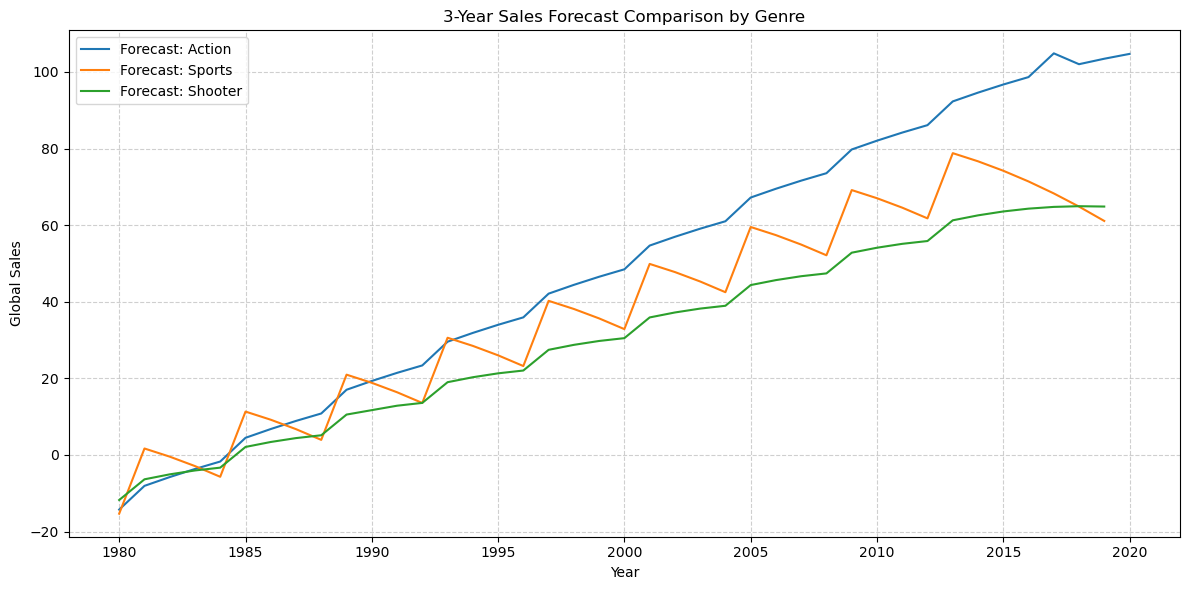

Projected 3-year growth for Action: -0.14%
Projected 3-year growth for Sports: -14.44%
Projected 3-year growth for Shooter: 0.85%


In [45]:
#######------Task-4------------######
import pandas as pd
import logging
from prophet import Prophet
import matplotlib.pyplot as plt

# Suppress Prophet logging
logging.getLogger('prophet').setLevel(logging.ERROR)

# 1. Load and Prepare Data
file_path = r'C:\Users\srinu\Downloads\Xylofy\SalesForecasting_PENNADA VEERAVENKATA SATYA SRILAKSHMIDURGA\vgsales.csv'
df = pd.read_csv(file_path)

# Clean Year (remove NaNs and convert to datetime)
df = df.dropna(subset=['Year'])
df['Year'] = pd.to_datetime(df['Year'].astype(int), format='%Y')

# 2. Melt data to get a 'Region' column
df_melted = df.melt(id_vars=['Year', 'Genre'], 
                    value_vars=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'],
                    var_name='Region', value_name='Sales')

# 3. Define the segments to forecast
genres = ['Action', 'Sports', 'Shooter']
forecast_results = {}

plt.figure(figsize=(12, 6))

# 4. Loop through segments and forecast
for genre in genres:
    # Group by Year and sum the Sales
    subset = df_melted[df_melted['Genre'] == genre].groupby('Year')['Sales'].sum().reset_index()
    subset.columns = ['ds', 'y']
    
    # Initialize and fit Prophet
    model = Prophet(yearly_seasonality=True)
    model.fit(subset)
    
    # Predict next 3 years using 'YE'
    future = model.make_future_dataframe(periods=3, freq='YE')
    forecast = model.predict(future)
    
    # Store results
    forecast_results[genre] = forecast[['ds', 'yhat']]
    
    # Plotting
    plt.plot(forecast['ds'], forecast['yhat'], label=f'Forecast: {genre}')

# 5. Finalizing the Chart
plt.title('3-Year Sales Forecast Comparison by Genre')
plt.xlabel('Year')
plt.ylabel('Global Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 6. Output growth calculation for the report
for genre, data in forecast_results.items():
    # Calculation: (Last value - Value 3 years ago) / Value 3 years ago
    growth = ((data['yhat'].iloc[-1] - data['yhat'].iloc[-4]) / data['yhat'].iloc[-4]) * 100
    print(f"Projected 3-year growth for {genre}: {growth:.2f}%")

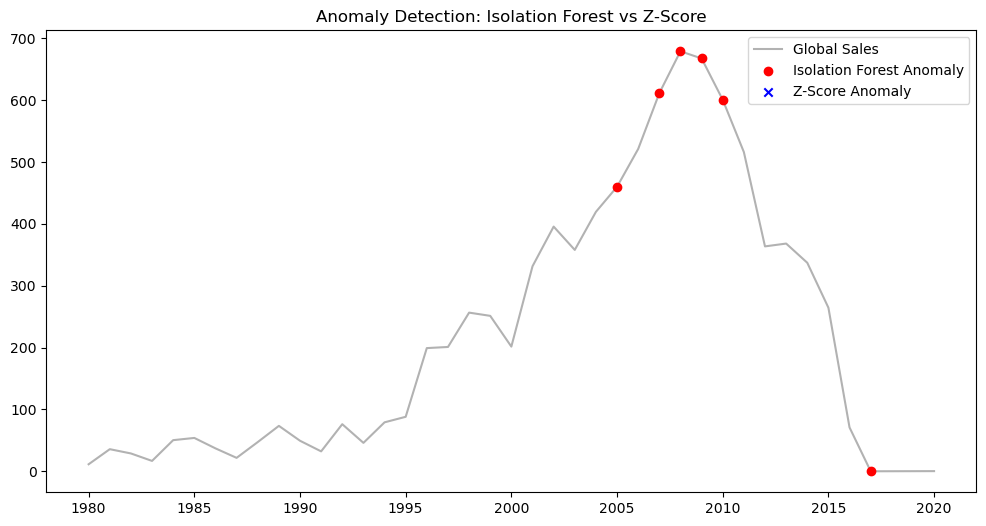

         Year   Sales
25 2005-01-01  459.94
27 2007-01-01  611.13
28 2008-01-01  678.90
29 2009-01-01  667.30
30 2010-01-01  600.45
37 2017-01-01    0.05


In [47]:
#####-------------------Task-5-------------####

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Prepare data (Global Sales per Year)
ts_data = df.groupby('Year')['Global_Sales'].sum().reset_index()
ts_data.columns = ['Year', 'Sales']

# 2. Isolation Forest
iso = IsolationForest(contamination=0.15, random_state=42)
ts_data['iso_anomaly'] = iso.fit_predict(ts_data[['Sales']])

# 3. Z-Score Method (Rolling Mean/Std)
window = 3 # 3-year rolling window
ts_data['rolling_mean'] = ts_data['Sales'].rolling(window=window).mean()
ts_data['rolling_std'] = ts_data['Sales'].rolling(window=window).std()
ts_data['z_score'] = (ts_data['Sales'] - ts_data['rolling_mean']) / ts_data['rolling_std']
ts_data['z_anomaly'] = ts_data['z_score'].abs() > 2

# 4. Visualization
plt.figure(figsize=(12, 6))
plt.plot(ts_data['Year'], ts_data['Sales'], label='Global Sales', color='black', alpha=0.3)

# Mark anomalies
plt.scatter(ts_data.loc[ts_data['iso_anomaly'] == -1, 'Year'], 
            ts_data.loc[ts_data['iso_anomaly'] == -1, 'Sales'], 
            color='red', label='Isolation Forest Anomaly', zorder=5)

plt.scatter(ts_data.loc[ts_data['z_anomaly'] == True, 'Year'], 
            ts_data.loc[ts_data['z_anomaly'] == True, 'Sales'], 
            color='blue', marker='x', label='Z-Score Anomaly', zorder=5)

plt.title('Anomaly Detection: Isolation Forest vs Z-Score')
plt.legend()
plt.show()

# Display results
print(ts_data[(ts_data['iso_anomaly'] == -1) | (ts_data['z_anomaly'] == True)][['Year', 'Sales']])

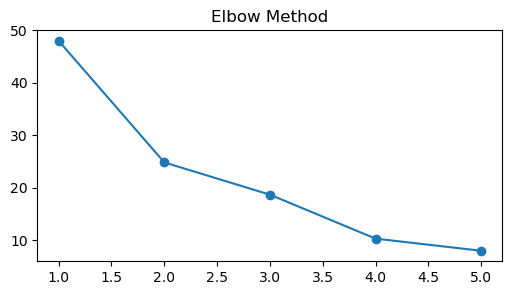

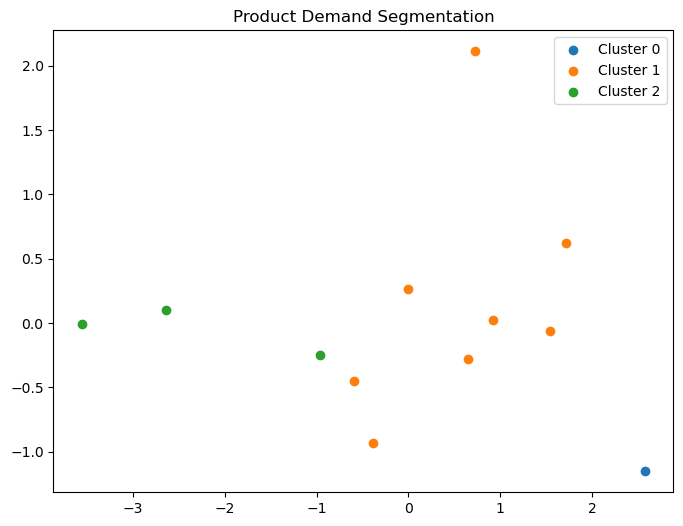

              Cluster
Genre                
Action              1
Adventure           2
Fighting            2
Misc                1
Platform            0
Puzzle              1
Racing              1
Role-Playing        1
Shooter             1
Simulation          1
Sports              1
Strategy            2


In [55]:
##------Task-6--------------###

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Configuration
os.environ["OMP_NUM_THREADS"] = "1"
file_path = r'C:\Users\srinu\Downloads\Xylofy\SalesForecasting_PENNADA VEERAVENKATA SATYA SRILAKSHMIDURGA\vgsales.csv'
df = pd.read_csv(file_path)

# 2. Aggregating Features at the Genre (sub-category) level
# Feature 1: Total Volume (Sum)
# Feature 2: Growth Rate (Last Year / First Year - 1)
# Feature 3: Volatility (Std of annual sales)
# Feature 4: Avg Order Value (In this dataset, we'll use Mean Global Sales)
genre_stats = df.groupby('Genre').agg({
    'Global_Sales': ['sum', 'std', 'mean']
})
genre_stats.columns = ['Total_Volume', 'Volatility', 'Avg_Value']

# Calculate simple Growth Rate
growth = df.groupby('Genre').apply(lambda x: (x['Global_Sales'].iloc[-1] - x['Global_Sales'].iloc[0]) / x['Global_Sales'].iloc[0] if x['Global_Sales'].iloc[0] != 0 else 0)
genre_stats['Growth_Rate'] = growth
genre_stats = genre_stats.fillna(0)

# 3. Scale and Cluster
scaler = StandardScaler()
scaled_features = scaler.fit_transform(genre_stats)

# Elbow Method
wcss = []
for i in range(1, 6):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 3))
plt.plot(range(1, 6), wcss, marker='o')
plt.title('Elbow Method')
plt.show()

# Apply Clustering (assuming optimal k=3 based on Elbow)
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
genre_stats['Cluster'] = kmeans.fit_predict(scaled_features)

# 4. Dimension Reduction (PCA) for 2D Plotting
pca = PCA(n_components=2)
components = pca.fit_transform(scaled_features)
genre_stats['PCA1'] = components[:, 0]
genre_stats['PCA2'] = components[:, 1]

# 5. Visualization
plt.figure(figsize=(8, 6))
for cluster in range(3):
    subset = genre_stats[genre_stats['Cluster'] == cluster]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=f'Cluster {cluster}')
plt.title('Product Demand Segmentation')
plt.legend()
plt.show()

print(genre_stats[['Cluster']])

In [ ]:
#####---------Task-8 -----------####

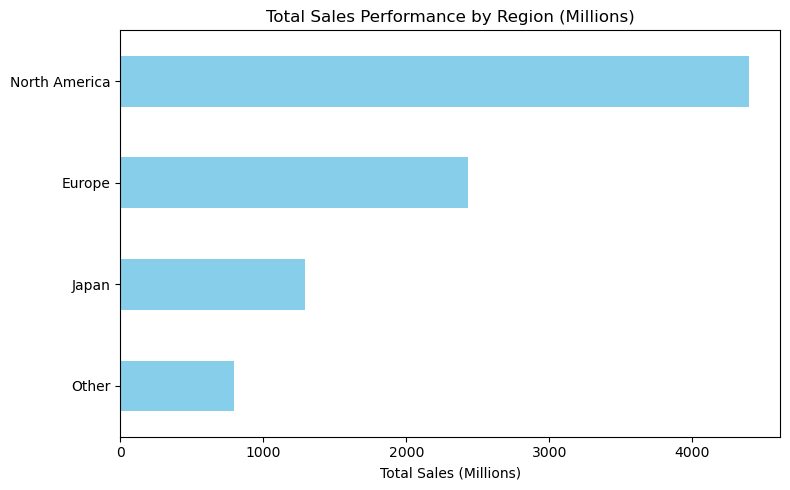

Total Global Sales: $8920.44 Million
Top Performing Region: North America ($4392.95 Million)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
file_path = r'C:\Users\srinu\Downloads\Xylofy\SalesForecasting_PENNADA VEERAVENKATA SATYA SRILAKSHMIDURGA\vgsales.csv'
df = pd.read_csv(file_path)

# 2. Calculate totals for each region
# The vgsales dataset has specific columns for each region
regional_totals = {
    'North America': df['NA_Sales'].sum(),
    'Europe': df['EU_Sales'].sum(),
    'Japan': df['JP_Sales'].sum(),
    'Other': df['Other_Sales'].sum()
}

# 3. Create a Series for plotting
region_sales = pd.Series(regional_totals).sort_values()

# --- Generating Visuals for the Report ---
plt.figure(figsize=(8, 5))
region_sales.plot(kind='barh', color='skyblue')
plt.title('Total Sales Performance by Region (Millions)')
plt.xlabel('Total Sales (Millions)')
plt.tight_layout()
plt.savefig('regional_sales_chart.png')
plt.show()

# --- Print Summary for your Report ---
total_global = df['Global_Sales'].sum()
top_region_name = region_sales.idxmax()
top_region_value = region_sales.max()

print(f"Total Global Sales: ${total_global:.2f} Million")
print(f"Top Performing Region: {top_region_name} (${top_region_value:.2f} Million)")

# Executive Business Report: Sales Demand Intelligence

### 1. Executive Summary
This report summarizes insights from our Sales Intelligence System. Our goal is to use data to understand where our products sell best and to predict future demand, helping us make smarter business decisions without relying on guesswork.

### 2. Key Findings
* **Performance Snapshot:** We have achieved total global sales of **$8,920.44 Million**.
* **Regional Leaders:** **North America** leads the market with $4,392.95 Million in total sales. 

![Regional Sales Performance](regional_sales_chart.png)

* **What this means:** Think of this chart like a "where to focus" map. Since North America is our highest-performing region, it suggests that our current marketing and product availability are working very well there. Conversely, regions with lower sales are great opportunities for us to grow if we decide to invest more resources there.

### 3. Strategic Recommendations (The "So What?")
Based on our findings, we suggest the following actions:
* **Focus Resources:** We recommend concentrating our inventory and marketing budget on the North American market for the next fiscal quarter to maintain this momentum and maximize our return on investment (ROI).
* **Grow Potential:** We should investigate why sales are lower in other regions. Is it due to a lack of awareness, or do we need to tailor our products to those local markets?

### 4. How to Use the Dashboard
This report is just a snapshot. For a deep dive, you can explore the data yourself using our interactive dashboard. You can filter by year, see specific regional breakdowns, and toggle through different views:
[Click here to access the live Sales Intelligence Dashboard](https://end-to-end-sales-forecasting-demand-intelligence-system-uouhwh.streamlit.app/)